In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Baris kode di atas merupakan bagian untuk mengimpor library yang dibutuhkan. Library numpy diimpor dengan alias np dan digunakan untuk melakukan operasi matematis pada array multidimensi yang merepresentasikan piksel gambar. Library matplotlib.pyplot diimpor dengan alias plt dan digunakan untuk menampilkan gambar maupun grafik histogram secara visual. Library cv2 diimpor dan digunakan khusus untuk membaca file gambar dari disk serta mengubahnya ke format grayscale.

In [2]:
backup = cv2.imread("backup.jpg", cv2.IMREAD_GRAYSCALE)
david = cv2.imread("david.jpg", cv2.IMREAD_GRAYSCALE)

Kode di atas digunakan untuk membaca dua file gambar bernama `backup.jpg` dan `david.jpg` menggunakan library OpenCV. Fungsi `cv2.imread()` berfungsi untuk mengambil gambar dari penyimpanan, kemudian parameter `cv2.IMREAD_GRAYSCALE` digunakan agar gambar langsung dikonversi menjadi citra grayscale (abu-abu) sehingga setiap piksel hanya memiliki satu nilai intensitas tanpa informasi warna RGB. Hasil pembacaan gambar kemudian disimpan ke dalam variabel `backup` dan `david` dalam bentuk matriks array.


In [3]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

Fungsi `filter_citra(img, size, mode)` digunakan untuk melakukan proses filtering pada citra grayscale menggunakan tiga jenis filter, yaitu mean, median, dan modus. Fungsi menerima parameter berupa gambar (`img`), ukuran kernel (`size`), serta jenis filter (`mode`). Pertama, program mengambil dimensi gambar lalu menambahkan padding tepi menggunakan `np.pad(..., mode='edge')` agar ukuran hasil akhir tetap sama dengan gambar asli. Selanjutnya dibuat variabel `canvas` sebagai tempat penyimpanan hasil filtering. Pada mode `mean`, nilai setiap piksel dihitung berdasarkan rata-rata seluruh piksel dalam area kernel. Pada mode `median`, program mengambil nilai tengah dari data setelah diurutkan secara manual menggunakan bubble sort untuk mengurangi noise. Sedangkan pada mode `modus`, program mencari nilai piksel yang paling sering muncul di dalam kernel. Setelah proses selesai, hasil filtering dikembalikan dalam bentuk citra baru melalui `return canvas`.


In [4]:
def convolution(img, kernel):
    # Ukuran kernel
    size = kernel.shape[0]
    
    # Ukuran padding
    pad_size = size // 2
    
    # Tambah padding nol (constant)
    padded = np.pad(img, pad_size, mode='constant')
    
    # Kanvas hasil (gunakan float32 untuk menampung nilai negatif/desimal)
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            # Hitung konvolusi: jumlah dari perkalian region dengan kernel
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

Kode di atas digunakan untuk melakukan proses konvolusi pada citra digital menggunakan berbagai jenis kernel filtering dan deteksi tepi. Fungsi `convolution(img, kernel)` menerima input berupa gambar grayscale dan matriks kernel, kemudian melakukan padding nol (`constant`) agar ukuran hasil tetap sama dengan gambar asli. Selanjutnya program melakukan pergeseran kernel ke setiap piksel gambar, mengambil area sesuai ukuran kernel (`region`), lalu menghitung hasil konvolusi dengan menjumlahkan perkalian elemen antara area gambar dan kernel menggunakan `np.sum(region * kernel)`. Hasil perhitungan disimpan pada `canvas` bertipe `float32` agar dapat menampung nilai negatif maupun desimal.

Pada bagian berikutnya, kode mendefinisikan beberapa kernel untuk berbagai kebutuhan pengolahan citra. `kernelSmoothing` digunakan untuk menghaluskan gambar dan mengurangi noise, sedangkan `kernelSharpening` digunakan untuk mempertajam detail citra. Selain itu terdapat kernel deteksi tepi seperti operator Sobel (`sobelx`, `sobely`), Prewitt (`prewittx`, `prewitty`), dan Roberts (`robertsx`, `robertsy`) yang digunakan untuk mendeteksi perubahan intensitas piksel pada arah horizontal maupun vertikal sehingga tepi objek pada citra dapat terlihat lebih jelas.


Kode di bawah ini digunakan untuk melakukan proses perbaikan citra pada gambar `backup` menggunakan teknik smoothing dan sharpening. Baris `backup_smooth = convolution(backup, kernelSmoothing)` menerapkan kernel smoothing untuk menghaluskan gambar dan mengurangi noise dengan cara meratakan nilai intensitas piksel di sekitar area kernel. Baris `backup_sharp = convolution(backup, kernelSharpening)` digunakan untuk mempertajam detail dan tepi objek pada citra sehingga gambar terlihat lebih jelas. Selanjutnya, `backup_smoothNsharp = backup_smooth + backup_sharp` menggabungkan hasil smoothing dan sharpening agar citra menjadi lebih halus namun tetap memiliki detail yang tajam.

Perbedaan utama dari ketiga metode tersebut terletak pada tujuan pengolahannya. Smoothing berfungsi untuk mengurangi noise dan membuat transisi antar piksel menjadi lebih lembut sehingga gambar tampak lebih halus, tetapi detail kecil dan tepi objek bisa menjadi blur. Sharpening digunakan untuk menonjolkan detail dan memperjelas tepi objek dengan meningkatkan kontras antar piksel sehingga hasil gambar terlihat lebih tajam. Sedangkan smoothing and sharpening merupakan kombinasi keduanya, yaitu mengurangi noise sekaligus mempertahankan atau meningkatkan ketajaman detail agar hasil citra lebih seimbang.

Jika dibandingkan dengan metode Mean, Median, dan Modus filtering, ketiganya juga memiliki perbedaan hasil. Mean filter menghasilkan gambar paling halus karena menggunakan rata-rata nilai piksel, tetapi efek blur cukup besar. Median filter mengambil nilai tengah sehingga lebih efektif menghilangkan noise tanpa terlalu merusak tepi objek, membuat hasil terlihat lebih natural dan tajam dibanding mean. Modus filter memilih nilai yang paling sering muncul di area kernel sehingga cocok mempertahankan nilai dominan pada citra, terutama pada area homogen. Secara umum, mean lebih fokus pada perataan, median lebih baik menjaga detail sambil mengurangi noise, sedangkan modus mempertahankan pola atau intensitas yang paling dominan di sekitar piksel.

Hasil perbedaan ketiga metode tersebut ditampilkan pada gambar di bawah ini.

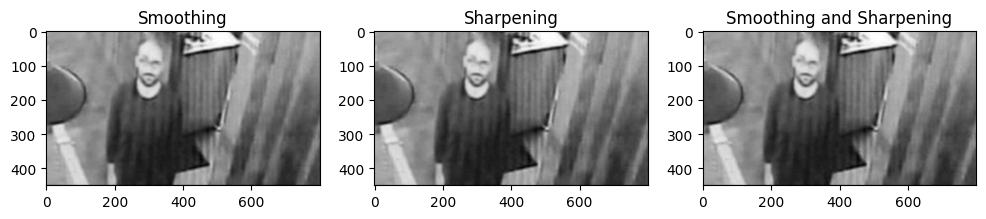

In [5]:
backup_smooth = convolution(backup, kernelSmoothing)
backup_sharp = convolution(backup, kernelSharpening)
backup_smoothNsharp = backup_smooth + backup_sharp

plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.title("Smoothing")
plt.imshow(backup_smooth, cmap='gray')
plt.subplot(1,3,2)
plt.title("Sharpening")
plt.imshow(backup_sharp, cmap='gray')
plt.subplot(1,3,3)
plt.title("Smoothing and Sharpening")
plt.imshow(backup_smoothNsharp, cmap='gray')

In [6]:
def edge_detection(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi `edge_detection(img, kernelx, kernely)` digunakan untuk mendeteksi tepi pada citra digital dengan memanfaatkan operator gradien seperti Sobel, Prewitt, atau Roberts. Pertama, fungsi melakukan proses konvolusi terhadap gambar menggunakan kernel horizontal (`kernelx`) dan vertikal (`kernely`) untuk memperoleh perubahan intensitas piksel pada sumbu x (`gx`) dan sumbu y (`gy`). Selanjutnya nilai absolut dari kedua gradien dijumlahkan agar seluruh hasil bernilai positif dan menghasilkan kekuatan tepi pada citra. Setelah itu dilakukan normalisasi ke rentang 0–255 supaya hasil dapat ditampilkan sebagai citra grayscale standar. Terakhir, fungsi menggunakan `np.clip()` untuk membatasi nilai piksel agar tidak melebihi rentang valid, kemudian hasil dikonversi menjadi tipe `uint8`. Fungsi ini menghasilkan gambar yang menampilkan bagian tepi objek secara lebih jelas dibanding area lainnya.

Kode di bawah ini digunakan untuk melakukan deteksi tepi pada citra `backup_smoothNsharp` menggunakan tiga operator berbeda, yaitu Prewitt, Sobel, dan Roberts. Fungsi `edge_detection()` dipanggil dengan kernel masing-masing operator untuk menghasilkan citra tepi berdasarkan perubahan intensitas piksel pada arah horizontal dan vertikal. Hasil deteksi tepi kemudian disimpan ke dalam variabel `smooth_sharp_prewitt`, `smooth_sharp_sobel`, dan `smooth_sharp_roberts`. Setelah itu, beberapa hasil operator digabungkan menggunakan operasi penjumlahan, seperti kombinasi Prewitt dan Sobel (`presob`), Prewitt dan Roberts (`prerob`), Sobel dan Roberts (`sobrob`), hingga kombinasi ketiga operator (`presobrob`) untuk menghasilkan informasi tepi yang lebih lengkap.

Operator Prewitt digunakan untuk mendeteksi tepi dengan perhitungan gradien sederhana sehingga cukup baik untuk mendeteksi garis horizontal dan vertikal dengan komputasi ringan. Operator Sobel memiliki konsep mirip Prewitt, tetapi memberikan bobot lebih besar pada piksel tengah sehingga hasil deteksi tepi biasanya lebih tajam dan lebih tahan terhadap noise. Sementara itu, operator Roberts menggunakan kernel berukuran 2×2 untuk mendeteksi perubahan intensitas secara diagonal sehingga mampu menangkap detail tepi kecil dan halus, tetapi lebih sensitif terhadap noise.

Kombinasi operator dilakukan untuk memanfaatkan kelebihan masing-masing metode. Kombinasi Prewitt dan Sobel menghasilkan deteksi tepi yang lebih stabil dan tajam. Kombinasi Prewitt dan Roberts dapat menangkap tepi umum sekaligus detail diagonal kecil. Kombinasi Sobel dan Roberts memberikan hasil tepi yang tajam dengan detail lebih rinci. Sedangkan kombinasi ketiga operator menghasilkan citra tepi yang lebih lengkap karena menggabungkan berbagai arah dan karakteristik deteksi tepi dari setiap operator.

Hasil dari penggunaan operator-operator tersebut ditampilkan pada gambar di bawah ini.

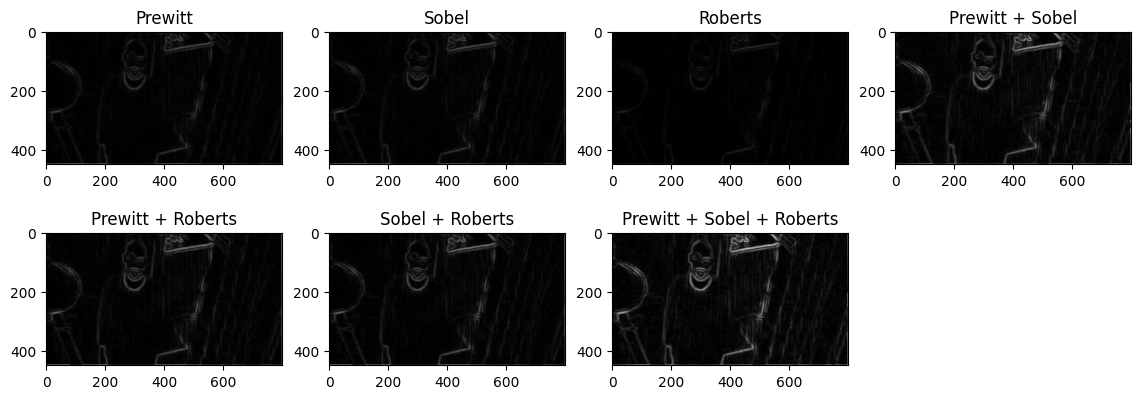

In [7]:
smooth_sharp_prewitt = edge_detection(backup_smoothNsharp, prewittx, prewitty)
smooth_sharp_sobel = edge_detection(backup_smoothNsharp, sobelx, sobely)
smooth_sharp_roberts = edge_detection(backup_smoothNsharp, robertsx, robertsy)
presob = smooth_sharp_prewitt + smooth_sharp_sobel
prerob = smooth_sharp_prewitt + smooth_sharp_roberts
sobrob = smooth_sharp_sobel + smooth_sharp_roberts
presobrob = smooth_sharp_prewitt + smooth_sharp_sobel + smooth_sharp_roberts

plt.figure(figsize=(14,10))
plt.subplot(4,4,1)
plt.title("Prewitt")
plt.imshow(smooth_sharp_prewitt, cmap='gray')
plt.subplot(4,4,2)
plt.title("Sobel")
plt.imshow(smooth_sharp_sobel, cmap='gray')
plt.subplot(4,4,3)
plt.title("Roberts")
plt.imshow(smooth_sharp_roberts, cmap='gray')

plt.subplot(4,4,4)
plt.title("Prewitt + Sobel")
plt.imshow(presob, cmap='gray')
plt.subplot(4,4,5)
plt.title("Prewitt + Roberts")
plt.imshow(prerob, cmap='gray')
plt.subplot(4,4,6)
plt.title("Sobel + Roberts")
plt.imshow(sobrob, cmap='gray')

plt.subplot(4,4,7)
plt.title("Prewitt + Sobel + Roberts")
plt.imshow(presobrob, cmap='gray')

In [8]:
def thresholding(image, angka):
    h, w = image.shape[:2]
    hasil = np.zeros((h,w), dtype=image.dtype)
    
    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

Fungsi `thresholding(image, angka)` digunakan untuk mengubah citra grayscale menjadi citra biner berdasarkan nilai ambang batas (threshold). Fungsi pertama-tama mengambil ukuran tinggi dan lebar gambar, kemudian membuat array kosong `hasil` dengan ukuran yang sama untuk menyimpan output. Selanjutnya program memeriksa setiap piksel pada gambar menggunakan perulangan. Jika nilai intensitas piksel lebih besar atau sama dengan nilai threshold (`angka`), maka piksel tersebut diubah menjadi putih dengan nilai `255`. Sebaliknya, jika nilainya lebih kecil dari threshold, piksel diubah menjadi hitam dengan nilai `0`. Proses ini menghasilkan citra biner yang memisahkan objek dan latar belakang.


Kode di bawah ini digunakan untuk menerapkan proses thresholding pada hasil deteksi tepi `smooth_sharp_prewitt` dengan beberapa nilai ambang berbeda, yaitu 10, 20, 30, 40, 50, dan 60. Setiap baris memanggil fungsi `thresholding()` untuk mengubah citra grayscale hasil operator Prewitt menjadi citra biner berdasarkan nilai threshold yang diberikan. Piksel dengan intensitas lebih besar atau sama dengan nilai threshold akan diubah menjadi putih (`255`), sedangkan piksel di bawah threshold akan menjadi hitam (`0`). Hasilnya disimpan dalam variabel berbeda seperti `thres10`, `thres20`, hingga `thres60`.

Perbedaan setiap citra yang dihasilkan terletak pada jumlah detail tepi yang ditampilkan. Pada `thres10`, nilai ambang sangat rendah sehingga hampir semua tepi dan noise kecil masih terlihat, menyebabkan gambar tampak lebih ramai. Pada `thres20` dan `thres30` beberapa noise mulai berkurang, tetapi detail tepi utama masih cukup jelas. Pada `thres40`, hasil biasanya menjadi lebih seimbang karena hanya tepi dengan intensitas cukup kuat yang dipertahankan. Sementara itu, pada `thres50` dan `thres60`, threshold semakin tinggi sehingga hanya tepi yang sangat kuat saja yang terlihat, membuat gambar tampak lebih bersih tetapi beberapa detail kecil dan tepi halus dapat hilang. Semakin besar nilai threshold, semakin sedikit piksel putih yang muncul pada citra hasil.

Pada kasus di bawah ini, nilai threshold yang bagus menggunakan nilai 10 karena detail dari objek maupun background-nya terdeteksi dengan baik.

Citra hasil threshold dapat dilihat pada gambar di bawah ini.

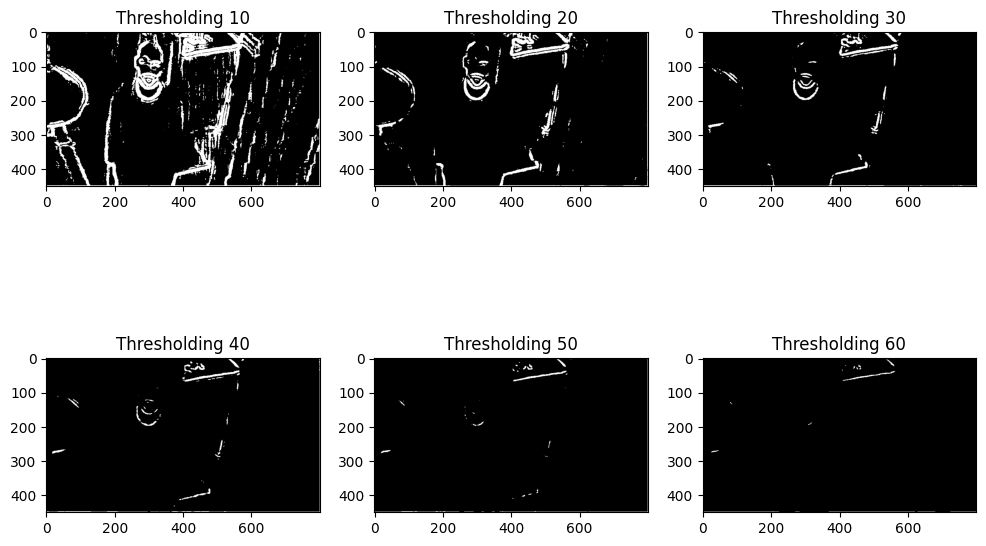

In [9]:
thres10 = thresholding(smooth_sharp_prewitt, 10)
thres20 = thresholding(smooth_sharp_prewitt, 20)
thres30 = thresholding(smooth_sharp_prewitt, 30)
thres40 = thresholding(smooth_sharp_prewitt, 40)
thres50 = thresholding(smooth_sharp_prewitt, 50)
thres60 = thresholding(smooth_sharp_prewitt, 60)

plt.figure(figsize=(12,12))

plt.subplot(3,3,1)
plt.title("Thresholding 10")
plt.imshow(thres10, cmap='gray')
plt.subplot(3,3,2)
plt.title("Thresholding 20")
plt.imshow(thres20, cmap='gray')
plt.subplot(3,3,3)
plt.title("Thresholding 30")
plt.imshow(thres30, cmap='gray')
plt.subplot(3,3,4)
plt.title("Thresholding 40")
plt.imshow(thres40, cmap='gray')
plt.subplot(3,3,5)
plt.title("Thresholding 50")
plt.imshow(thres50, cmap='gray')
plt.subplot(3,3,6)
plt.title("Thresholding 60")
plt.imshow(thres60, cmap='gray')

In [10]:
def manual_median_filter(mask, ksize=3):
    h, w = mask.shape
    pad = ksize // 2
    padded_img = np.pad(mask, pad, mode='constant', constant_values=0)
    output_mask = np.zeros_like(mask)

    for i in range(h):
        for j in range(w):
            window = padded_img[i : i + ksize, j : j + ksize]
            # Mencari nilai tengah manual dengan sorting
            flat_window = window.flatten()
            sorted_window = np.sort(flat_window)
            output_mask[i, j] = sorted_window[len(sorted_window) // 2]
    return output_mask

def manual_convolution(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad = kh // 2
    padded_img = np.pad(img, pad, mode='constant', constant_values=0)
    res = np.zeros_like(img, dtype=float)
    
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+kh, j:j+kw]
            res[i, j] = np.sum(region * kernel)
    return res

def process_rgb_pipeline(image_rgb, ksize=5):
    img = np.array(image_rgb)
    h, w, c = img.shape
    
    # DETEKSI BACKGROUND TOSKA (Berdasarkan Perbandingan Kanal RGB)
    bg_mask = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            r, g, b = img[i, j].astype(int)
            # Hijau & Biru dominan dibanding Merah
            if g > r + 25 and b > r + 25:
                bg_mask[i, j] = 255 # Tandai sebagai background
    
    # CLEANING MASK (Median Filtering)
    cleaned_bg_mask = manual_median_filter(bg_mask, ksize)
    
    # Inversi mask: 255 untuk OBJEK, 0 untuk BACKGROUND
    obj_mask = 255 - cleaned_bg_mask

    # DETEKSI TEPI (Prewitt pada Grayscale)
    gray = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)
    kx = np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]])
    ky = np.array([[1, 1, 1],[0, 0, 0],[-1, -1, -1]])
    
    gx = manual_convolution(gray, kx)
    gy = manual_convolution(gray, ky)
    edge_mag = np.sqrt(gx**2 + gy**2)
    # Normalisasi tepi
    if edge_mag.max() > 0:
        edge_mag = (edge_mag / edge_mag.max() * 255).astype(np.uint8)
    
    # HASIL AKHIR (Objek Asli, Background Putih)
    final_res = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            if obj_mask[i, j] == 255:
                # Jika area objek, ambil warna asli dari citra RGB
                final_res[i, j] = img[i, j]
            else:
                # Jika background, buat jadi putih
                final_res[i, j] = [255, 255, 255]
                
    return edge_mag, obj_mask, final_res

def highlight_cctv_pipeline(image_path):
    # 1. Load dan konversi ke RGB
    img_bgr = cv2.imread(image_path)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Pembuatan Mask (Thresholding RGB)
    mask = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            r, g, b = img[i, j].astype(int)
            # Jika intensitas rata-rata di bawah ambang (subjek gelap)
            if (r + g + b) / 3 < 170 and (r + g + b) / 3 > 120: 
                mask[i, j] = 255
    
    # Bersihkan mask dengan Median Filter agar tidak berbintik
    mask_clean = manual_median_filter(mask, ksize=3)

    # Deteksi Tepi pada Mask (Garis Luar Siluet)
    kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    ky = np.array([[-1, -1, -1], [ 0,  0,  0], [ 1,  1,  1]])
    gx = manual_convolution(mask_clean, kx)
    gy = manual_convolution(mask_clean, ky)
    edge = np.sqrt(gx**2 + gy**2)
    edge = (edge > 50).astype(np.uint8) * 255 # Binarisasi tepi

    # Overlay Highlight (Warna Kuning pada Tepi)
    highlight_res = img.copy()
    for i in range(h):
        for j in range(w):
            if edge[i, j] == 255:
                # warna kuning [R=255, G=255, B=0] pada garis tepi
                highlight_res[i, j] = [255, 255, 0]

    return mask_clean, edge, highlight_res

Fungsi `manual_median_filter()` digunakan untuk mengurangi noise pada citra biner dengan metode median filter. Fungsi ini mengambil area kernel di sekitar piksel, mengurutkan nilainya, lalu memilih nilai tengah sebagai hasil baru sehingga noise kecil dapat dihilangkan tanpa terlalu merusak bentuk objek.

Fungsi `manual_convolution()` digunakan untuk melakukan operasi konvolusi secara manual antara citra dan kernel tertentu. Proses ini dilakukan dengan menggeser kernel ke seluruh area gambar, kemudian menghitung jumlah perkalian antara nilai piksel dan kernel. Fungsi ini menjadi dasar untuk berbagai proses pengolahan citra seperti smoothing, sharpening, dan deteksi tepi.

Fungsi `process_rgb_pipeline()` merupakan pipeline pengolahan citra RGB yang terdiri dari beberapa tahap. Pertama, program mendeteksi background berwarna toska berdasarkan perbandingan kanal RGB dengan mencari area yang memiliki nilai hijau dan biru lebih dominan dibanding merah. Setelah itu dilakukan median filtering untuk membersihkan noise pada mask. Kemudian mask dibalik agar objek menjadi putih dan background hitam. Selanjutnya citra dikonversi menjadi grayscale lalu dilakukan deteksi tepi menggunakan operator Prewitt melalui kernel horizontal dan vertikal. Pada tahap akhir, objek asli dipertahankan menggunakan warna RGB aslinya sedangkan background diubah menjadi putih sehingga objek tampak lebih jelas.

Sementara itu, fungsi `highlight_cctv_pipeline()` digunakan untuk menyoroti objek pada citra CCTV. Program membaca gambar lalu membuat mask berdasarkan rentang intensitas warna untuk memisahkan objek gelap dari background terang. Setelah noise dibersihkan menggunakan median filter, dilakukan deteksi tepi menggunakan operator untuk memperoleh garis luar siluet objek. Tepi yang terdeteksi kemudian diberi overlay warna kuning pada citra asli sehingga objek pada gambar CCTV tampak lebih menonjol dan mudah dikenali.

Kode di bawah ini digunakan untuk menampilkan hasil proses dari fungsi `highlight_cctv_pipeline("backup.jpg")` dalam bentuk visual. Fungsi `highlight_cctv_pipeline` dijalankan untuk menghasilkan tiga output, yaitu `mask` (hasil segmentasi objek), `outline` (hasil deteksi tepi), dan `hasil` (gambar akhir dengan highlight objek).

Hasil pengolahan citra tersebut ditampilkan pada gambar di bawah ini. Untuk objek manusianya tidak terdeteksi dengan sempurna kayak di soal, cuman okelah.

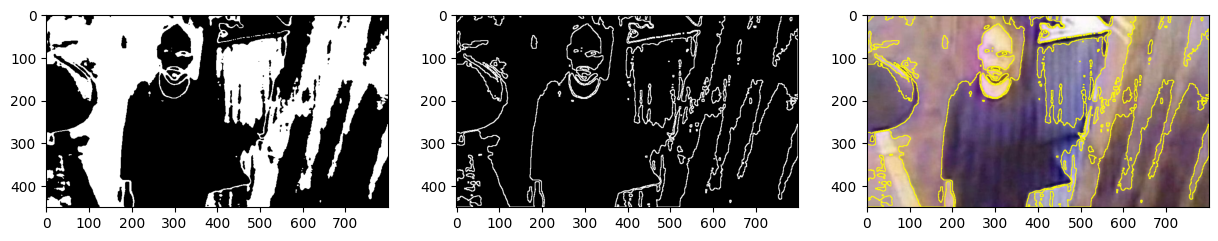

In [11]:
plt.figure(figsize=(15,5))
mask, outline, hasil = highlight_cctv_pipeline("backup.jpg")
plt.subplot(131)
plt.imshow(mask, cmap='gray')
plt.subplot(132)
plt.imshow(outline, cmap='gray')
plt.subplot(133)
plt.imshow(hasil, cmap='gray')

Kode di bawah ini digunakan untuk menampilkan hasil pemrosesan citra dari fungsi `process_rgb_pipeline()` pada gambar `david.jpg`. Pertama, gambar dibaca menggunakan `plt.imread()` dan disimpan ke dalam variabel `david_img`. Selanjutnya, fungsi `process_rgb_pipeline(david_img)` dipanggil untuk menghasilkan tiga output, yaitu `tepi` (hasil deteksi tepi objek), `mask_putih` (mask objek hasil segmentasi dengan objek berwarna putih dan background hitam), serta `hasil_akhir` (citra akhir di mana objek dipertahankan dan background diubah menjadi putih).

Hasil pengolahan citranya dapat dilihat pada gambar di bawah ini.

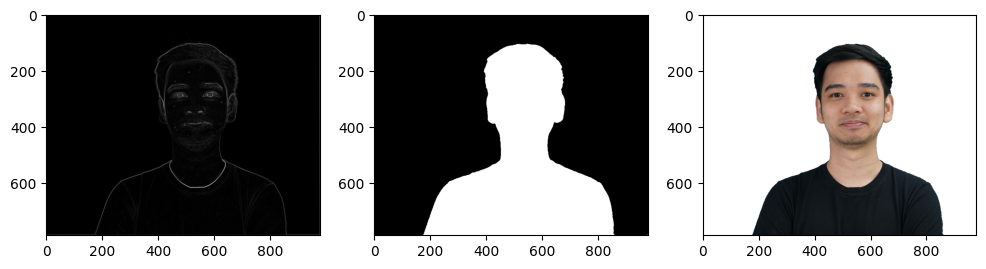

In [12]:
david_img = plt.imread("david.jpg")
tepi, mask_putih, hasil_akhir = process_rgb_pipeline(david_img)

plt.figure(figsize=(12,8))

plt.subplot(131)
plt.imshow(tepi, cmap='gray')
plt.subplot(132)
plt.imshow(mask_putih, cmap='gray')
plt.subplot(133)
plt.imshow(hasil_akhir)

Kesimpulannya, perbaikan kualitas citra dan deteksi tepi merupakan dua proses penting yang saling melengkapi dalam pengolahan citra digital untuk meningkatkan informasi visual yang dapat dianalisis dari sebuah gambar.

Perbaikan kualitas citra seperti filtering (mean, median, modus), smoothing, sharpening, serta kombinasi keduanya bertujuan untuk membersihkan noise, memperjelas detail, dan menyeimbangkan kualitas gambar. Proses ini membuat citra lebih siap pakai untuk analisis lanjutan karena gangguan seperti noise atau ketidakjelasan detail dapat dikurangi sehingga struktur objek lebih mudah dikenali.

Sementara itu, deteksi tepi (edge detection) seperti menggunakan operator Sobel, Prewitt, dan Roberts berfungsi untuk mengekstraksi informasi penting berupa batas objek. Dengan menyoroti perubahan intensitas piksel yang signifikan, proses ini membantu memisahkan objek dari latar belakang, mengenali bentuk, serta memahami struktur visual dalam citra.
